In [3]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

import kagglehub


In [ ]:
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print("Downloaded Path:", path)

subdirs = os.listdir(path)
print("Folder Contents:", subdirs)


In [10]:
print(f"Listing the concise file structure for: {path}\n")

MAX_FILES_TO_SHOW = 3

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)

    print(f'{indent}{os.path.basename(root)}/')

    subindent = ' ' * 4 * (level + 1)
    for i, f in enumerate(files):
        if i < MAX_FILES_TO_SHOW:
            print(f'{subindent}{f}')
        else:
            print(f'{subindent}... ({len(files) - MAX_FILES_TO_SHOW} more files)')
            break

Listing the concise file structure for: /kaggle/input/plant-disease-recognition-dataset

plant-disease-recognition-dataset/
    Validation/
        Validation/
            Healthy/
                9d0f6e60819f9a5a.jpg
                9ccf708985967f09.jpg
                9ccbc2c5d1aaf078.jpg
                ... (17 more files)
            Rust/
                8219aa662e8fd59d.jpg
                929b16251fcaafc4.jpg
                851edcf908ed2e1c.jpg
                ... (17 more files)
            Powdery/
                9ab326c1951acb7a.jpg
                9bd06de433b285d8.jpg
                9ad5df40909ae24f.jpg
                ... (17 more files)
    Test/
        Test/
            Healthy/
                8e8470687be37378.jpg
                8def3f60308ab41b.jpg
                8ddaac1bd6c8cd0a.jpg
                ... (47 more files)
            Rust/
                93e896990cb365b5.jpg
                85f0c2c0db4b4f4f.jpg
                89bc19fcf830c6e8.jpg
                ..

Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
Downloaded Path: /kaggle/input/plant-disease-recognition-dataset
Folder Contents: ['Validation', 'Test', 'Train']
Resolved DATA_DIR: /kaggle/input/plant-disease-recognition-dataset/Train/Train

=== Class Distribution ===
  • Healthy: 458 images
  • Powdery: 430 images
  • Rust: 434 images

Imbalance Ratio (Max / Min): 1.07


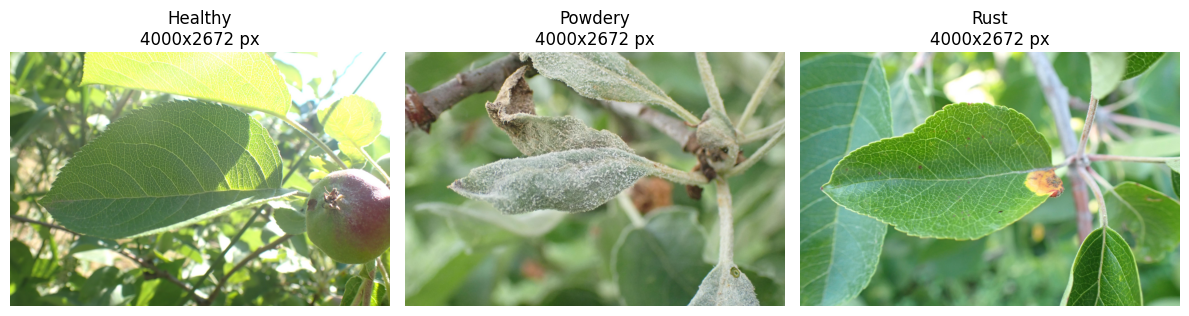

In [13]:

if "Train" in subdirs:
    current_data_root = os.path.join(path, "Train")
    if "Train" in os.listdir(current_data_root) and os.path.isdir(os.path.join(current_data_root, "Train")):
        DATA_DIR = os.path.join(current_data_root, "Train")
    else:
        DATA_DIR = current_data_root
elif "train" in subdirs:
    current_data_root = os.path.join(path, "train")
    if "train" in os.listdir(current_data_root) and os.path.isdir(os.path.join(current_data_root, "train")):
        DATA_DIR = os.path.join(current_data_root, "train")
    else:
        DATA_DIR = current_data_root
elif "Plant_leave_diseases_dataset" in subdirs:
    DATA_DIR = os.path.join(path, "Plant_leave_diseases_dataset")
else:
    DATA_DIR = path

print("Resolved DATA_DIR:", DATA_DIR)

# Check Class Names & Distribution
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
class_counts = {}

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    images = glob.glob(os.path.join(cls_path, "*.[jJ][pP][gG]"))

    class_counts[cls] = len(images)

print("\n=== Class Distribution ===")
for cls, count in class_counts.items():
    print(f"  • {cls}: {count} images")


# Display Sample Images
if class_names:
    fig, axes = plt.subplots(1, len(class_names), figsize=(12, 4))
    for idx, cls in enumerate(class_names):
        cls_path = os.path.join(DATA_DIR, cls)
        sample_files = glob.glob(os.path.join(cls_path, "*.*[gG]"))
        if sample_files:
            sample_file = sample_files[0]
            img = Image.open(sample_file)
            ax = axes[idx] if len(class_names) > 1 else axes
            ax.imshow(img)
            ax.set_title(f"{cls}\n{img.size[0]}x{img.size[1]} px")
            ax.axis("off")
        else:
            ax = axes[idx] if len(class_names) > 1 else axes
            ax.set_title(f"{cls}\nNo images found")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


In [15]:
import tensorflow as tf

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

NUM_CLASSES = len(full_ds.class_names)
print(f"\nSuccessfully loaded {NUM_CLASSES} classes: {full_ds.class_names}")

ds_size = len(full_ds)
train_size = int(0.8 * ds_size)
val_size = int(0.1 * ds_size)

train_ds = full_ds.take(train_size)
val_ds = full_ds.skip(train_size).take(val_size)
test_ds = full_ds.skip(train_size + val_size)

print(f"Total Batches: {ds_size}")
print(f"  • Train Batches: {len(train_ds)}")
print(f"  • Validation Batches: {len(val_ds)}")
print(f"  • Test Batches: {len(test_ds)}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1322 files belonging to 3 classes.

Successfully loaded 3 classes: ['Healthy', 'Powdery', 'Rust']
Total Batches: 42
  • Train Batches: 33
  • Validation Batches: 4
  • Test Batches: 5


In [16]:
from tensorflow import keras
from tensorflow.keras import layers

config_model_a = {
    "name": "Model_A_Baseline",
    "filters": [32, 64],
    "kernel_size": (3, 3),
    "batch_norm": False,
    "dropout": 0.0
}

def build_cnn(num_classes: int, config: dict) -> keras.Model:
    inputs = keras.Input(shape=(64, 64, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)

    for filters in config["filters"]:
        x = layers.Conv2D(filters, kernel_size=config["kernel_size"], padding="same")(x)
        if config["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    if config["dropout"] > 0.0:
        x = layers.Dropout(config["dropout"])(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=config["name"])

model_a = build_cnn(num_classes=NUM_CLASSES, config=config_model_a)
model_a.summary()

Model: "Model_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,587 (76.51 KB)

 Trainable params: 19,587 (76.51 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
config_model_b = {
    "name": "Model_B_Deeper",
    "filters": [32, 64, 128],
    "kernel_size": (3, 3),
    "batch_norm": False,
    "dropout": 0.0
}

model_b = build_cnn(num_classes=NUM_CLASSES, config=config_model_b)
model_b.summary()

model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Training Model B (Deeper) ---")
history_b = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Model: "Model_B_Deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,635 (365.76 KB)

 Trainable params: 93,635 (365.76 KB)

 Non-trainable params: 0 (0.00 B)

--- Training Model B (Deeper) ---
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 298ms/step - accuracy: 0.4280 - loss: 1.0449 - val_accuracy: 0.5469 - val_loss: 0.9084
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 295ms/step - accuracy: 0.6316 - loss: 0.7932 - val_accuracy: 0.6484 - val_loss: 0.7400
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 261ms/step - accuracy: 0.6752 - loss: 0.7022 - val_accuracy: 0.6641 - val_loss: 0.7114
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - accuracy: 0.7140 - loss: 0.6523 - val_accuracy: 0.6797 - val_loss: 0.7087
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step - accuracy: 0.7424 - loss: 0.6131 - val_accuracy: 0.7266 - val_loss: 0.6425
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step - accuracy: 0.7812 - loss: 0.5403 - val_accuracy: 0.7109 - val_loss: 0.6425
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.7955 - loss: 0.5074 - val_accuracy: 0.7422 - val_loss: 0.6152
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 

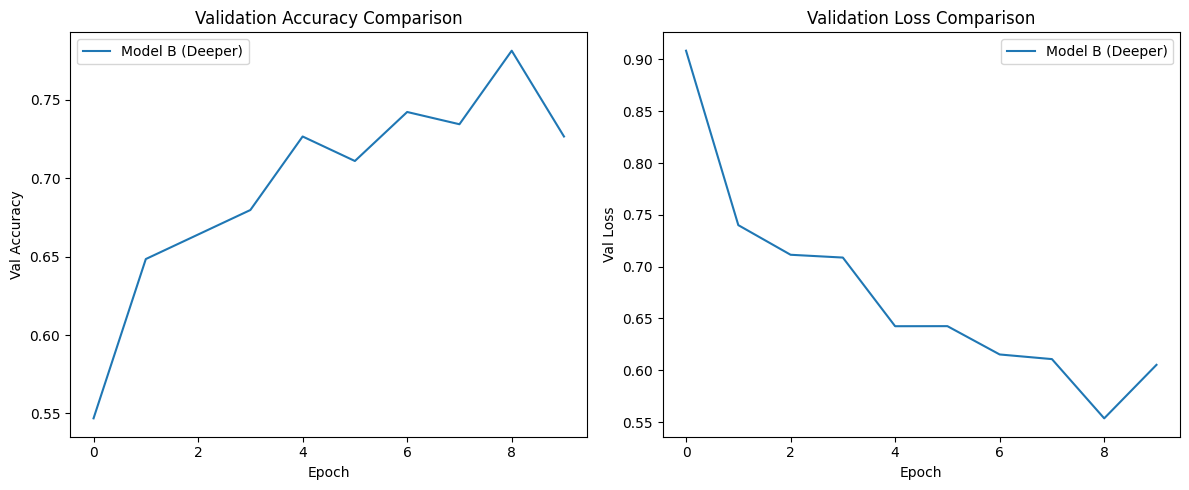

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_b.history['val_accuracy'], label='Model B (Deeper)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_b.history['val_loss'], label='Model B (Deeper)')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()

plt.tight_layout()
plt.show()